In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [5]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels shape (50000,1) → (50000,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("After preprocessing:", x_train.shape)

After preprocessing: (50000, 32, 32, 3)


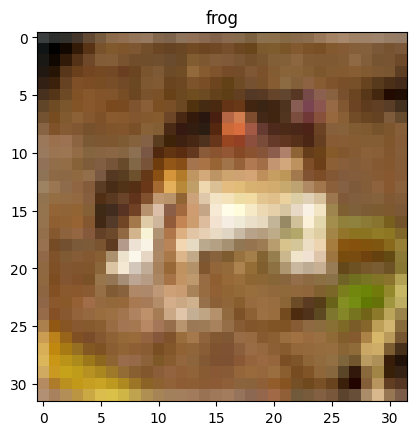

In [6]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(x_train[0])
plt.title(class_names[y_train[0]])
plt.show()

In [7]:
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
 59/704 ━━━━━━━━━━━━━━━━━━━━ 5:19 495ms/step - accuracy: 0.8411 - loss: 0.4540

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8122 - loss: 0.5581
Test Accuracy: 0.8090000152587891


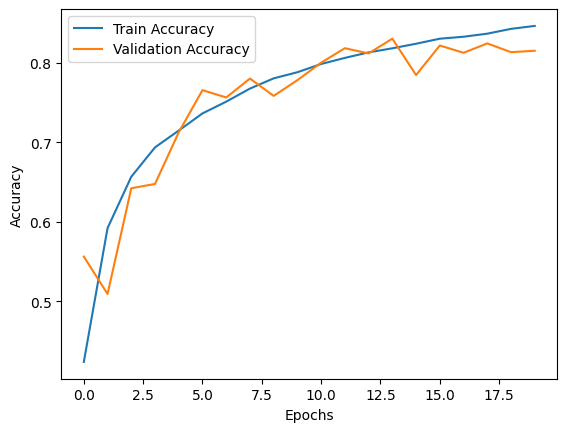

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [12]:
prediction = model.predict(x_test[0:1])
predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Predicted: cat
Actual: cat
